In [1]:
import pandas as pd
import numpy as np
import ast
from typing import List, Optional, Tuple
import matplotlib.pyplot as plt

In [3]:
def str_to_2d_array(string: str) -> Optional[np.ndarray]:
    """
    Convert a string representation of a 2D array to a NumPy array.
    
    Args:
        string: String representation of a 2D array
        
    Returns:
        NumPy array if conversion is successful, None otherwise
    """
    if ',' not in string:
        string = string.replace(' ', ',')
    try:
        list_of_lists = ast.literal_eval(string)
        return np.array(list_of_lists)
    except (ValueError, SyntaxError):
        return None

In [19]:
def cell_volume(cell: np.ndarray) -> float:
    """Return unit-cell volume from a 3x3 lattice matrix.

    The volume is |det(cell)|. This is equivalent to |a · (b × c)|,
    where a,b,c are the lattice vectors (rows of cell by convention here).

    Units: if cell is in Å, volume is Å^3.
    """
    cell = np.asarray(cell, dtype=float)
    if cell.shape != (3, 3):
        raise ValueError(f"Expected shape (3,3), got {cell.shape}")
    return float(abs(np.linalg.det(cell)))

### Load data

In [6]:
df_dft = pd.read_csv('./dft_result.csv', index_col=0)
df_ml  = pd.read_csv('./mattersim_result.csv', index_col=0)

# Sort both dataframes by 'composition' to ensure alignment
df_dft = df_dft.sort_values('composition')
df_ml = df_ml.sort_values('composition')

### Compare MLIP formation energy with DFT results

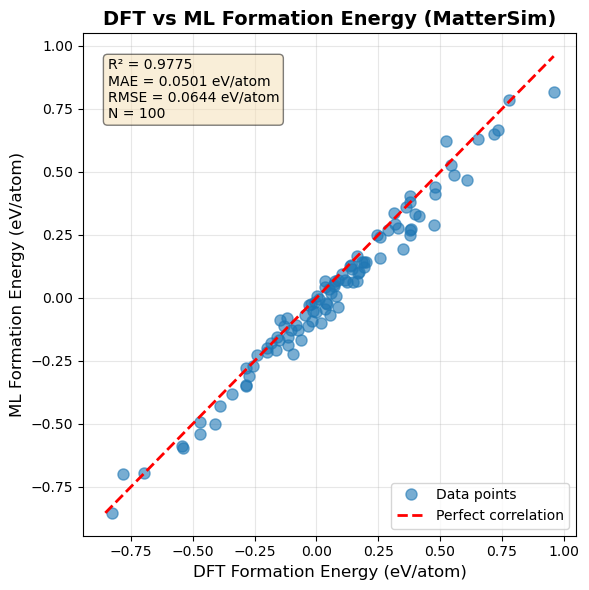

In [22]:
dft = df_dft['Formation Energy (eV/atom)']
ml  = df_ml['Formation Energy (eV/atom)']

# Create improved plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(dft, ml, 'o', markersize=8, alpha=0.6, label='Data points')

# Add perfect correlation line
min_val = min(min(dft), min(ml))
max_val = max(max(dft), max(ml))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect correlation')

# Calculate statistics
dft_arr = np.array(dft)
ml_arr = np.array(ml)
correlation = np.corrcoef(dft_arr, ml_arr)[0, 1]
r_squared = correlation ** 2
mae = np.mean(np.abs(dft_arr - ml_arr))
rmse = np.sqrt(np.mean((dft_arr - ml_arr) ** 2))

# Add labels and title
ax.set_xlabel('DFT Formation Energy (eV/atom)', fontsize=12)
ax.set_ylabel('ML Formation Energy (eV/atom)', fontsize=12)
ax.set_title('DFT vs ML Formation Energy (MatterSim)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text box
stats_text = f'R² = {r_squared:.4f}\nMAE = {mae:.4f} eV/atom\nRMSE = {rmse:.4f} eV/atom\nN = {len(dft)}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('dft_vs_ml_formation_energy_mattersim.png', dpi=300)
plt.show()


### Compare MLIP Distance above convex hull with DFT results

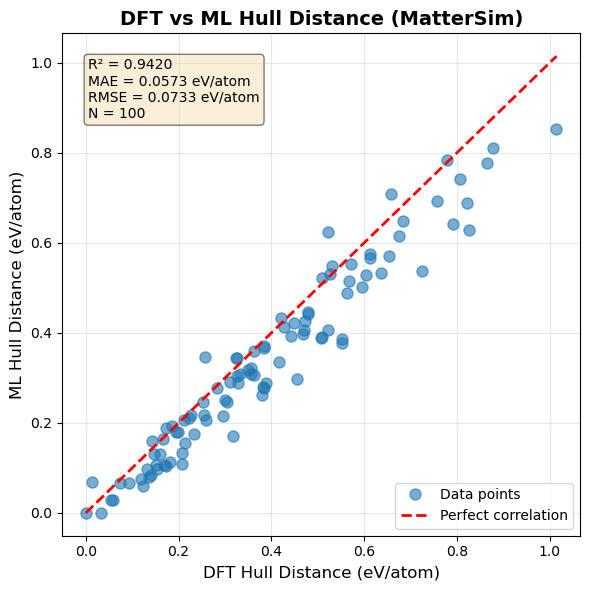

In [24]:
dft = df_dft['Hull Distance (eV/atom)']
ml  = df_ml['Hull Distance (eV/atom)']

# Create improved plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(dft, ml, 'o', markersize=8, alpha=0.6, label='Data points')

# Add perfect correlation line
min_val = min(min(dft), min(ml))
max_val = max(max(dft), max(ml))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect correlation')

# Calculate statistics
dft_arr = np.array(dft)
ml_arr = np.array(ml)
correlation = np.corrcoef(dft_arr, ml_arr)[0, 1]
r_squared = correlation ** 2
mae = np.mean(np.abs(dft_arr - ml_arr))
rmse = np.sqrt(np.mean((dft_arr - ml_arr) ** 2))

# Add labels and title
ax.set_xlabel('DFT Hull Distance (eV/atom)', fontsize=12)
ax.set_ylabel('ML Hull Distance (eV/atom)', fontsize=12)
ax.set_title('DFT vs ML Hull Distance (MatterSim)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text box
stats_text = f'R² = {r_squared:.4f}\nMAE = {mae:.4f} eV/atom\nRMSE = {rmse:.4f} eV/atom\nN = {len(dft)}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('dft_vs_ml_hull_distance_mattersim.png', dpi=300)
plt.show()


### Compare MLIP cell parameter with DFT results

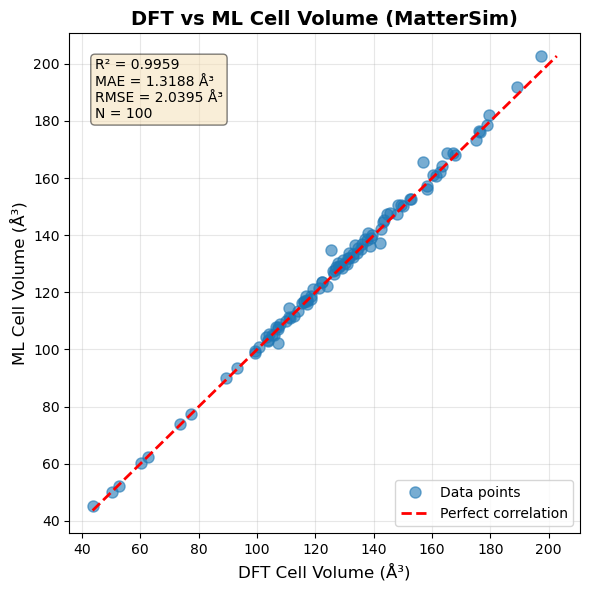

In [26]:
dft = []
ml  = []

for _, row in df_dft.iterrows():
    cell = str_to_2d_array(row['cell'])
    dft.append(cell_volume(cell))

for _, row in df_ml.iterrows():
    cell = str_to_2d_array(row['optimized_cell'])
    ml.append(cell_volume(cell))

# Create improved plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(dft, ml, 'o', markersize=8, alpha=0.6, label='Data points')

# Add perfect correlation line
min_val = min(min(dft), min(ml))
max_val = max(max(dft), max(ml))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect correlation')

# Calculate statistics
dft_arr = np.array(dft)
ml_arr = np.array(ml)
correlation = np.corrcoef(dft_arr, ml_arr)[0, 1]
r_squared = correlation ** 2
mae = np.mean(np.abs(dft_arr - ml_arr))
rmse = np.sqrt(np.mean((dft_arr - ml_arr) ** 2))

# Add labels and title
ax.set_xlabel('DFT Cell Volume (Å³)', fontsize=12)
ax.set_ylabel('ML Cell Volume (Å³)', fontsize=12)
ax.set_title('DFT vs ML Cell Volume (MatterSim)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text box
stats_text = f'R² = {r_squared:.4f}\nMAE = {mae:.4f} Å³\nRMSE = {rmse:.4f} Å³\nN = {len(dft)}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('dft_vs_ml_cell_volume_mattersim.png', dpi=300)
plt.show()


### Merge figures

In [31]:
from PIL import Image

In [33]:
png_paths = [
    'dft_vs_ml_cell_volume_mattersim.png',
    'dft_vs_ml_formation_energy_mattersim.png',
    'dft_vs_ml_hull_distance_mattersim.png',
]

# Merge three PNGs side-by-side into one PNG
output_path = 'dft_vs_ml_mattersim.png'

In [ ]:
# If you want to override the filenames, edit `png_paths` in the next cell.
images = [Image.open(p).convert('RGBA') for p in png_paths]

# Use the smallest height to avoid upscaling
target_h = min(im.height for im in images)
resized = [
    im.resize((int(round(im.width * target_h / im.height)), target_h), Image.Resampling.LANCZOS)
    if im.height != target_h else im
    for im in images
 ]

total_w = sum(im.width for im in resized)
merged = Image.new('RGBA', (total_w, target_h), (255, 255, 255, 0))

x = 0
for im in resized:
    merged.paste(im, (x, 0), im)
    x += im.width

merged.save(output_path)
print(f'Saved: {output_path}')

Saved: dft_vs_ml_mattersim.png
